In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

X_ode = np.load("ODE.npy")
dt_ode, t0_ode, te_ode = 0.01, 0, 2
m, N, n = X_ode.shape
X_ode.shape

(200, 201, 2)

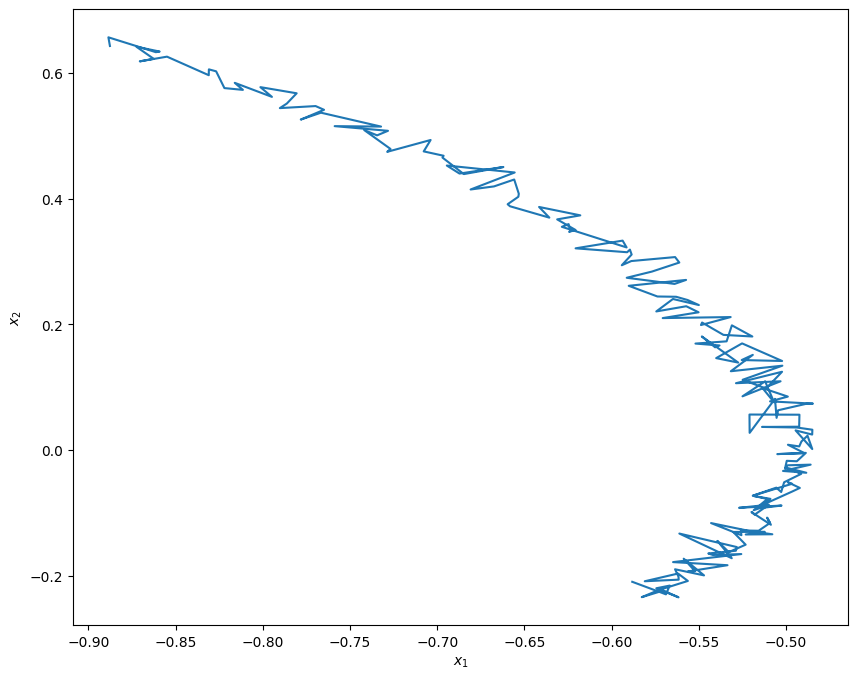

In [48]:

plt.figure(figsize=(10, 8))
for traj in X_ode[2:3,:,:]:
    plt.plot(traj[:,0], traj[:,1])
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
plt.show()

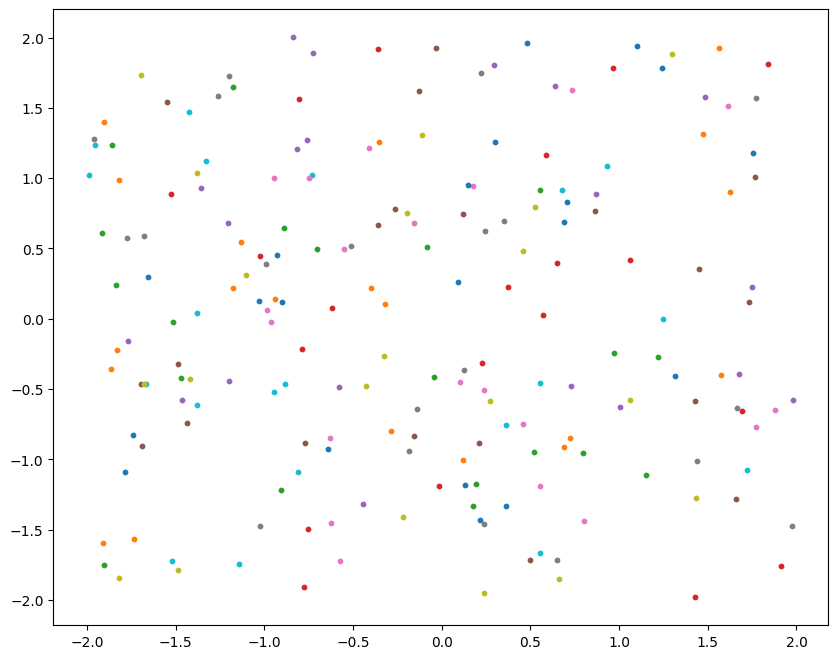

1


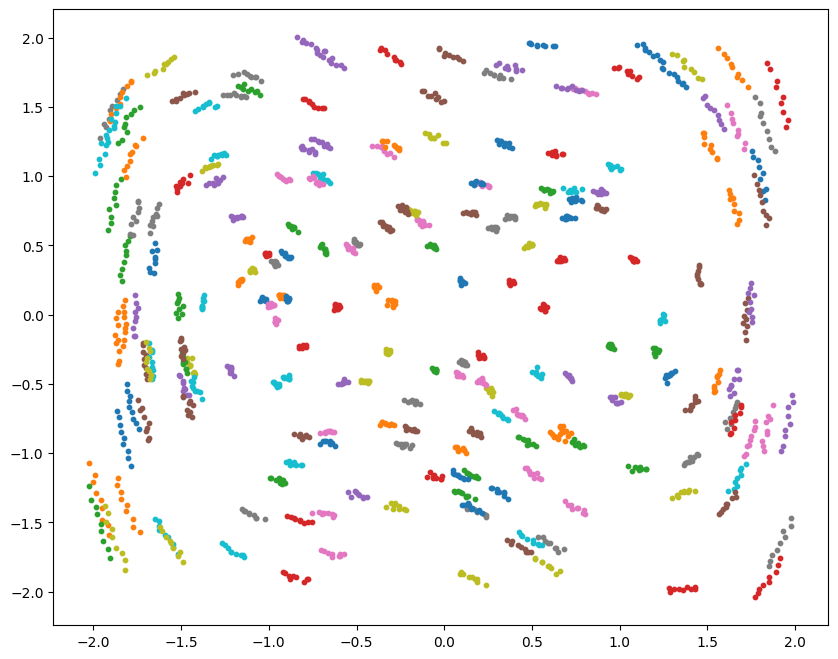

9


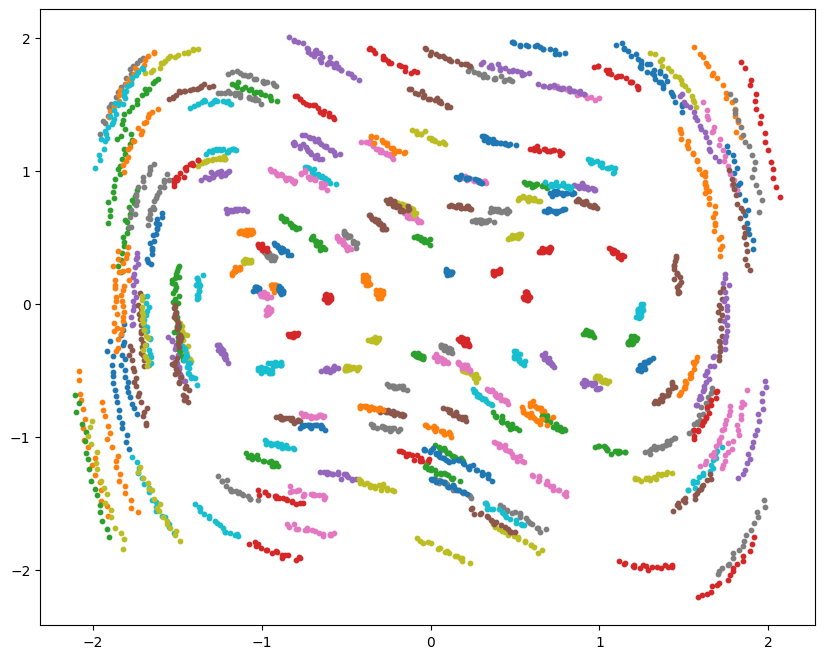

17


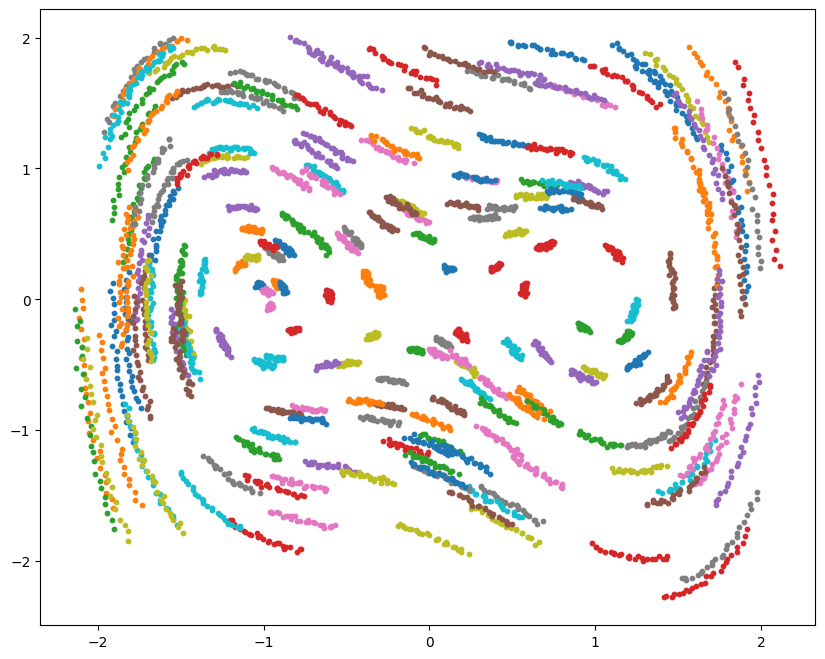

25


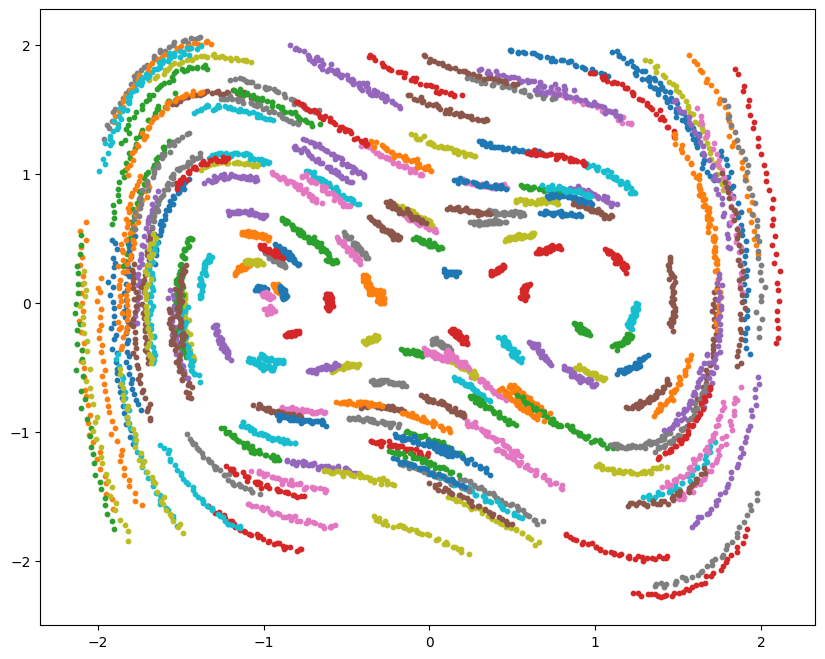

33


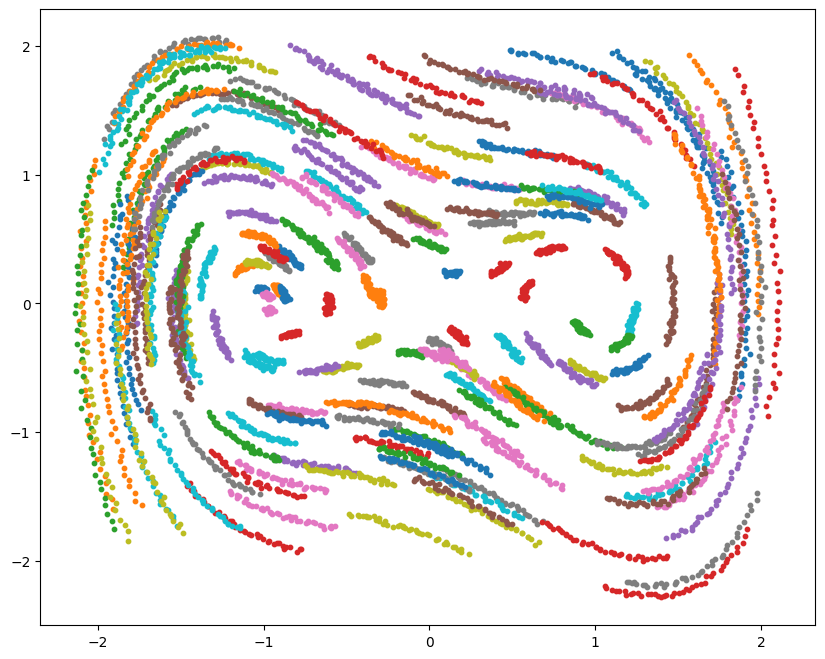

41


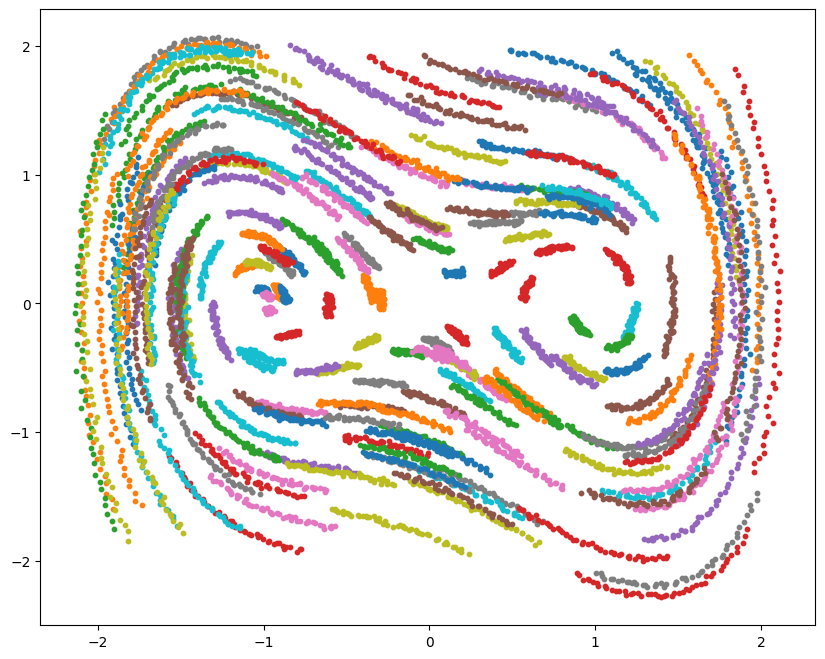

49


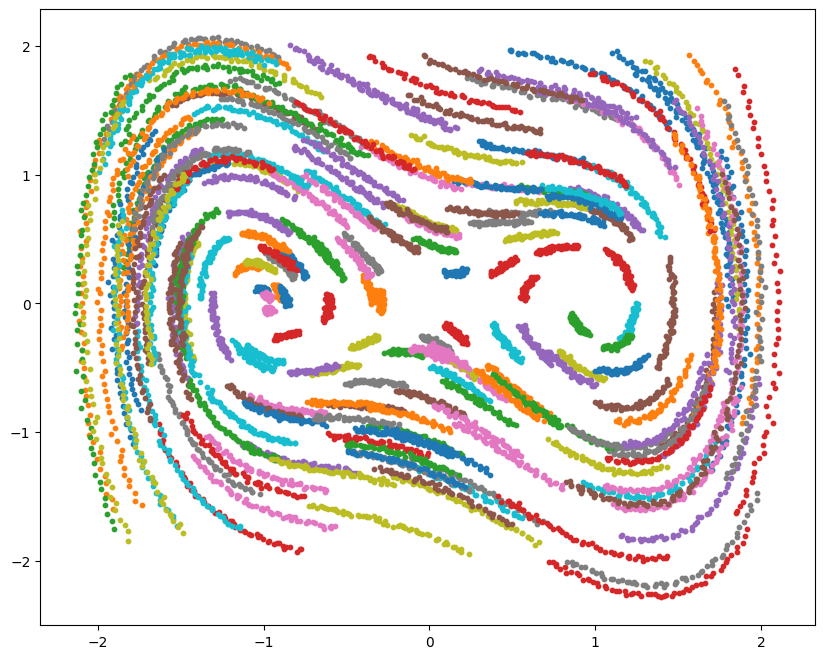

57


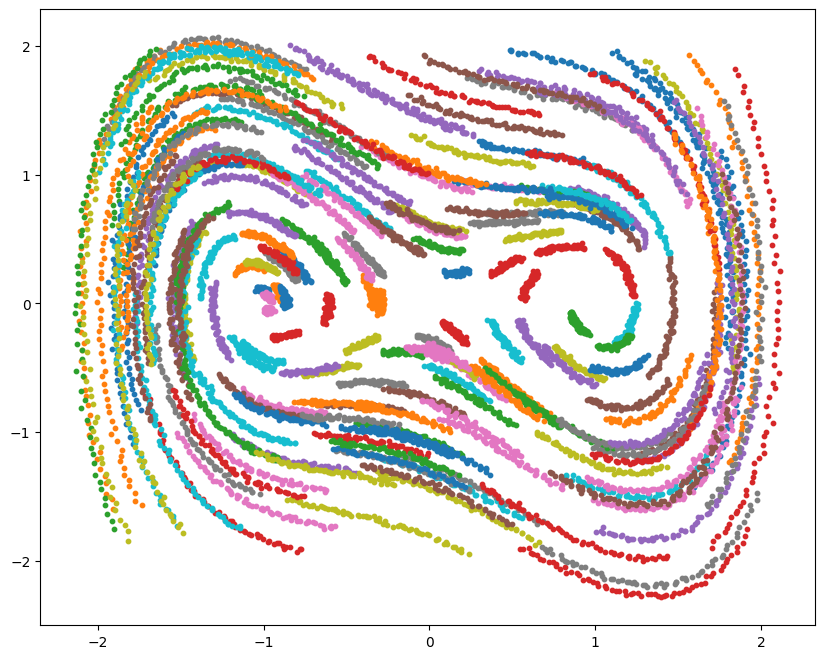

65


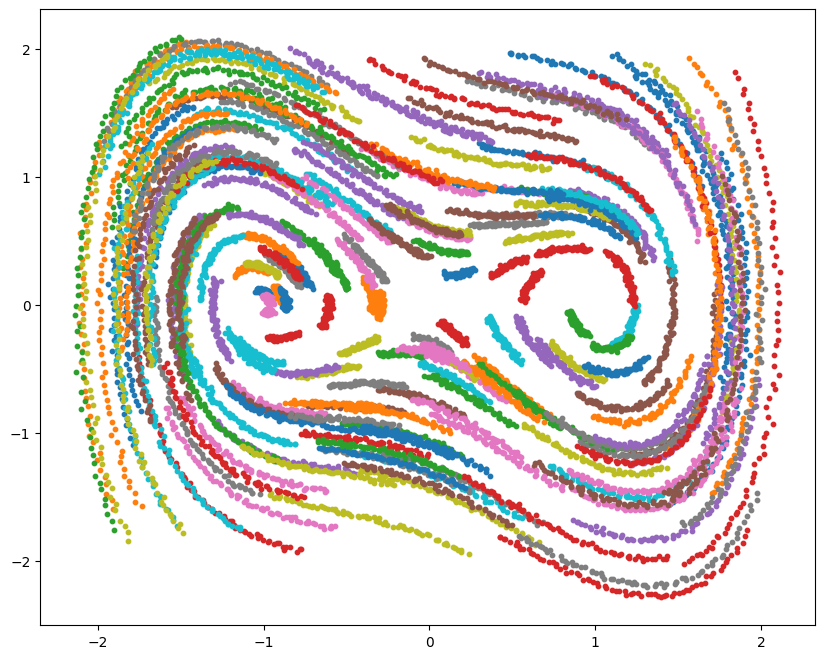

73


In [49]:
for x in range(1,80, 8):
    plt.figure(figsize=(10, 8))
    for traj in X_ode[:,:x,:]:
        plt.scatter(x=traj[:,0], y=traj[:,1],s=10)
    plt.show()
    print(x)


In [50]:
import numpy as np
from scipy.signal import savgol_filter

def sg_smooth_and_derivative(X, dt, window_length=21, polyorder=3, axis=-2):
    """
    X: array (..., T, D) or (n_traj, T, D)
    dt: timestep
    axis: the time axis (default -2 assumes last dims are (T, D))
    returns: X_smooth, Xdot_smooth (same shape as X)
    """
    # window_length must be odd and > polyorder
    if window_length % 2 == 0:
        window_length += 1
    if window_length <= polyorder:
        window_length = polyorder + 2 + (polyorder % 2 == 0)  # make it odd-ish

    X_smooth = savgol_filter(X, window_length=window_length, polyorder=polyorder,
                             deriv=0, delta=dt, axis=axis, mode="interp")

    Xdot_smooth = savgol_filter(X, window_length=window_length, polyorder=polyorder,
                                deriv=1, delta=dt, axis=axis, mode="interp")
    return X_smooth, Xdot_smooth


# Example usage:
# If X_ode shape is (n_traj, T, 2)
dt = 0.01  # your timestep
X_smooth, Xdot_smooth = sg_smooth_and_derivative(X_ode, dt, window_length=31, polyorder=3, axis=1)
X_ode = X_smooth
Xdot = Xdot_smooth

In [51]:
def compute_derivatives(X, dt):
    """
    X: (m, N, n) trajectories
    returns:
        X_flat: (M, n)
        Xdot_flat: (M, n)
    where M = m * (N - 2)  (due to central difference)
    """
    m, N, n = X.shape
    X_list, Xdot_list = [], []

    for traj in X:  # (N, n)
        # central differences for interior points. SINDY requires velocities. CD measures velocities.
        x = traj
        xdot = (x[2:, :] - x[:-2, :]) / (2 * dt)  # (N-2, n)computing the central difference. startinf from 2 to x200 and then leaving the last two behind. 
        X_mid = x[1:-1, :]                        # (N-2, n)

        X_list.append(X_mid)
        Xdot_list.append(xdot)

    X_flat = np.vstack(X_list) #Stack everything vertically like a big tower.
    Xdot_flat = np.vstack(Xdot_list)
    return X_flat, Xdot_flat #two matrices are produced.

X_flat, Xdot_flat = compute_derivatives(X_ode, dt_ode)
print(X_flat.shape, Xdot_flat.shape)

(39800, 2) (39800, 2)


In [52]:
#here, we are spliting the data into 2- training data (80%) and test data (20%)
#39800=no. of data points
#2=no. of variables
M = X_flat.shape[0] #gives 39800
np.random.seed(1042002)
idx = np.random.permutation(M) #creates like a shuffled list of indices because we want random training data.
train_size = int(0.8 * M)

train_idx = idx[:train_size]
test_idx = idx[train_size:]

X_train, Xdot_train = X_flat[train_idx], Xdot_flat[train_idx]
X_test,  Xdot_test  = X_flat[test_idx], Xdot_flat[test_idx]



#now we have training data on which sindy will train the data on
#20% test data on which the ODE will be checked. 

In [53]:
def build_library(X, poly_order=3, include_sine=False):
    #polyorder= how high the polynomials should go
    """
    X: (M, n)
    returns Theta: (M, p) feature matrix and feature_names
    """
    M, n = X.shape
    Theta_list = [] #stores feature columns.
    '''building a menu of ingredients-list of possible terms it can use.
    each row of theta is a data point. columns are features'''
    names = [] #stores feature names as strings

    # constant
    Theta_list.append(np.ones((M, 1)))
    names.append("1") #appending 1 for constant terms such as x˙=3+2x

    # linear
    for i in range(n):
        Theta_list.append(X[:, i:i+1])
        names.append(f"x{i+1}")

    if poly_order >= 2:
        for i in range(n):
            for j in range(i, n):
                Theta_list.append((X[:, i] * X[:, j])[:, None])
                names.append(f"x{i+1} x{j+1}")

    if poly_order >= 3:
        for i in range(n):
            for j in range(i, n):
                for k in range(j, n):
                    Theta_list.append((X[:, i] * X[:, j] * X[:, k])[:, None])
                    names.append(f"x{i+1} x{j+1} x{k+1}")

    if include_sine:
        for i in range(n):
            Theta_list.append(np.sin(X[:, i:i+1]))
            names.append(f"sin(x{i+1})")

    Theta = np.hstack(Theta_list)
    return Theta, names

Theta_train, lib_names = build_library(X_train, poly_order=3, include_sine=False)
Theta_test,  _         = build_library(X_test,  poly_order=3, include_sine=False)

print(Theta_train.shape)
print(lib_names[:10])

(31840, 10)
['1', 'x1', 'x2', 'x1 x1', 'x1 x2', 'x2 x2', 'x1 x1 x1', 'x1 x1 x2', 'x1 x2 x2', 'x2 x2 x2']


In [54]:
import numpy as np
from scipy.signal import savgol_filter

def sg_smooth_and_derivative(X, dt, window_length=21, polyorder=3, axis=-2):
    """
    X: array (..., T, D) or (n_traj, T, D)
    dt: timestep
    axis: the time axis (default -2 assumes last dims are (T, D))
    returns: X_smooth, Xdot_smooth (same shape as X)
    """
    # window_length must be odd and > polyorder
    if window_length % 2 == 0:
        window_length += 1
    if window_length <= polyorder:
        window_length = polyorder + 2 + (polyorder % 2 == 0)  # make it odd-ish

    X_smooth = savgol_filter(X, window_length=window_length, polyorder=polyorder,
                             deriv=0, delta=dt, axis=axis, mode="interp")

    Xdot_smooth = savgol_filter(X, window_length=window_length, polyorder=polyorder,
                                deriv=1, delta=dt, axis=axis, mode="interp")
    return X_smooth, Xdot_smooth


# Example usage:
# If X_ode shape is (n_traj, T, 2)
dt = 0.01  # your timestep
X_smooth, Xdot_smooth = sg_smooth_and_derivative(X_ode, dt, window_length=31, polyorder=3, axis=1)


In [55]:
#SINDY learns the equation
#theta- library of all functions (coefficients)
#Xi- discovered equation. a matrix of coefficients telling which features matter.
#alpha- regularisation parameter for lasso (controls sparsity). LASSO-keeps only what matters and dumps the rest.
def fit_sindy(Theta, Xdot, alpha=1e-4):
    """
    Theta: (M, p)
    Xdot: (M, n)
    returns Xi: (p, n) sparse coefficient matrix
    """
    M, p = Theta.shape
    _, n = Xdot.shape
    Xi = np.zeros((p, n))

    #Xi- later, LASSO finds these values. it is set to zero for now.

    for k in range(n):
        model = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
        model.fit(Theta, Xdot[:, k]) #the feature set is used to predict Xdot
        Xi[:, k] = model.coef_
    return Xi

#Xi is now the coeeficient matrix we need.

Xi = fit_sindy(Theta_train, Xdot_train, alpha=1e-4)
print("Discovered Dynamics (Training Set)")

for k in range(n):
    print(f"\nDynamics for x_{k+1}:")
    for coef, name in zip(Xi[:, k], lib_names):
        if abs(coef) > 1e-6:
            print(f"  {coef:+.4f} * {name}")
print('\n\n')
# Evaluate on test set
print("Test Set Evaluation")
test_mse = np.zeros(n)
for k in range(n):
    Xdot_pred_test = Theta_test @ Xi[:, k]
    test_mse[k] = mean_squared_error(Xdot_test[:, k], Xdot_pred_test)
    print(f"x_{k+1} test MSE: {test_mse[k]:.6f}")

print(f"\nOverall test MSE: {np.mean(test_mse):.6f}")

# Save the learned coefficients for later use
np.save("Xi_learned.npy", Xi)
print("\nModel saved as 'Xi_learned.npy'")

Discovered Dynamics (Training Set)

Dynamics for x_1:
  -0.0001 * x1
  +0.9988 * x2
  +0.0003 * x1 x2
  +0.0000 * x2 x2
  +0.0008 * x1 x1 x2
  +0.0002 * x1 x2 x2
  +0.0003 * x2 x2 x2

Dynamics for x_2:
  +0.9980 * x1
  -0.4992 * x2
  -0.0002 * x1 x1
  -0.0006 * x1 x2
  -0.0003 * x2 x2
  -0.9985 * x1 x1 x1
  +0.0008 * x1 x1 x2
  -0.0009 * x2 x2 x2



Test Set Evaluation
x_1 test MSE: 0.003607
x_2 test MSE: 0.003696

Overall test MSE: 0.003651

Model saved as 'Xi_learned.npy'


In [56]:
#SINDY learns the equation
#theta- library of all functions (coefficients)
#Xi- discovered equation. a matrix of coefficients telling which features matter.
#alpha- regularisation parameter for lasso (controls sparsity). LASSO-keeps only what matters and dumps the rest.
def fit_sindy(Theta, Xdot, alpha=1e-4):
    """
    Theta: (M, p)
    Xdot: (M, n)
    returns Xi: (p, n) sparse coefficient matrix
    """
    M, p = Theta.shape
    _, n = Xdot.shape
    Xi = np.zeros((p, n))

    #Xi- later, LASSO finds these values. it is set to zero for now.

    for k in range(n):
        # Solve the least squares problem to find coefficients
        Xi[:, k] = np.linalg.lstsq(Theta, Xdot[:, k], rcond=None)[0]
    return Xi

#Xi is now the coeeficient matrix we need.

Xi = fit_sindy(Theta_train, Xdot_train, alpha=1e-4)
print("Discovered Dynamics (Training Set)")

for k in range(n):
    print(f"\nDynamics for x_{k+1}:")
    for coef, name in zip(Xi[:, k], lib_names):
        if abs(coef) > 1e-6:
            print(f"  {coef:+.4f} * {name}")
print('\n\n')
# Evaluate on test set
print("Test Set Evaluation")
test_mse = np.zeros(n)
for k in range(n):
    Xdot_pred_test = Theta_test @ Xi[:, k]
    test_mse[k] = mean_squared_error(Xdot_test[:, k], Xdot_pred_test)
    print(f"x_{k+1} test MSE: {test_mse[k]:.6f}")

print(f"\nOverall test MSE: {np.mean(test_mse):.6f}")

# Save the learned coefficients for later use
np.save("Xi_learned_lstsq.npy", Xi)
print("\nModel saved as 'Xi_learned.npy'")

Discovered Dynamics (Training Set)

Dynamics for x_1:
  -0.0002 * 1
  -0.0007 * x1
  +0.9989 * x2
  +0.0001 * x1 x1
  +0.0005 * x1 x2
  +0.0003 * x2 x2
  +0.0001 * x1 x1 x1
  +0.0009 * x1 x1 x2
  +0.0005 * x1 x2 x2
  +0.0003 * x2 x2 x2

Dynamics for x_2:
  +0.0004 * 1
  +0.9990 * x1
  -0.4998 * x2
  -0.0004 * x1 x1
  -0.0009 * x1 x2
  -0.0006 * x2 x2
  -0.9989 * x1 x1 x1
  +0.0011 * x1 x1 x2
  -0.0001 * x1 x2 x2
  -0.0008 * x2 x2 x2



Test Set Evaluation
x_1 test MSE: 0.003606
x_2 test MSE: 0.003696

Overall test MSE: 0.003651

Model saved as 'Xi_learned.npy'


In [57]:
np.var(Xdot_test[:, k])*10/100


np.float64(0.15185078904345942)

In [58]:
def library_single_x(x, poly_order=3, include_sine=False):
    """
    x: (n,) single state
    returns phi(x): (p,)
    using the same ordering as build_library
    """
    x = np.asarray(x)
    n = x.shape[0]
    features = [1.0]

    # linear
    for i in range(n):
        features.append(x[i])

    # quadratic
    if poly_order >= 2:
        for i in range(n):
            for j in range(i, n):
                features.append(x[i] * x[j])

    # cubic
    if poly_order >= 3:
        for i in range(n):
            for j in range(i, n):
                for k in range(j, n):
                    features.append(x[i] * x[j] * x[k])

    if include_sine:
        for i in range(n):
            features.append(np.sin(x[i]))

    return np.array(features)


def f_learned(x, Xi, poly_order=3, include_sine=False):
    phi = library_single_x(x, poly_order=poly_order, include_sine=include_sine)
    return phi @ Xi   # (n,)

#RK- ODE simulation method
def rk4_step(x, dt, rhs, *rhs_args):
    k1 = rhs(x, *rhs_args) #like asking 4 times where the system is going and taking an average of the four outputs.
    k2 = rhs(x + 0.5*dt*k1, *rhs_args)
    k3 = rhs(x + 0.5*dt*k2, *rhs_args)
    k4 = rhs(x + dt*k3, *rhs_args)
    return x + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0

#generates a state vector of where the point is goign to be in time dt.

In [59]:
def simulate_learned_ode(X_ode, Xi, n_steps=100, dt_data=0.01, substeps=5):
    """
    Evaluate learned ODE model on random initial conditions chosen from
    the first 301 time steps (or less, if the trajectory is shorter).

    X_ode: (m, N, n) array of trajectories
    Xi:    (p, n) coefficient matrix from SINDy
    """
    m, N, n = X_ode.shape
    dt_sim = dt_data / substeps

    # number of ICs
    num_ics = 20
    rng = np.random.default_rng(0)

    # how many steps can we actually take, given the data?
    max_horizon = min(n_steps, N - 1, 300)   # at most 300 as stated in the exam
    if max_horizon < 1:
        raise ValueError("Not enough time steps in the data for the chosen n_steps.")

    # start indices only where we have enough future data
    max_start = min(301, N) - max_horizon - 1
    if max_start < 0:
        max_start = 0

    traj_idx = rng.integers(0, m, size=num_ics)
    time_idx = rng.integers(0, max_start + 1, size=num_ics)

    mses = []

    for ti, ki in zip(traj_idx, time_idx):
        # take a segment of length (max_horizon + 1)
        x0 = X_ode[ti, ki].copy()
        x_true = X_ode[ti, ki:ki + max_horizon + 1]   # (T+1, n)
        T = x_true.shape[0] - 1                      # actual number of steps

        # allocate simulation array with the same length
        x_sim = np.zeros_like(x_true)
        x_sim[0] = x0

        for k in range(T):
            x = x_sim[k].copy()
            for _ in range(substeps):
                x = rk4_step(x, dt_sim, f_learned, Xi)
            x_sim[k + 1] = x

        mses.append(mean_squared_error(x_true, x_sim))

    return float(np.mean(mses)), mses


mean_mse, all_mses = simulate_learned_ode(X_ode, Xi)
print("Mean trajectory MSE:", mean_mse)
# Mean trajectory MSE: 0.0002705108724724893


Mean trajectory MSE: 1.5382284512893804e-05


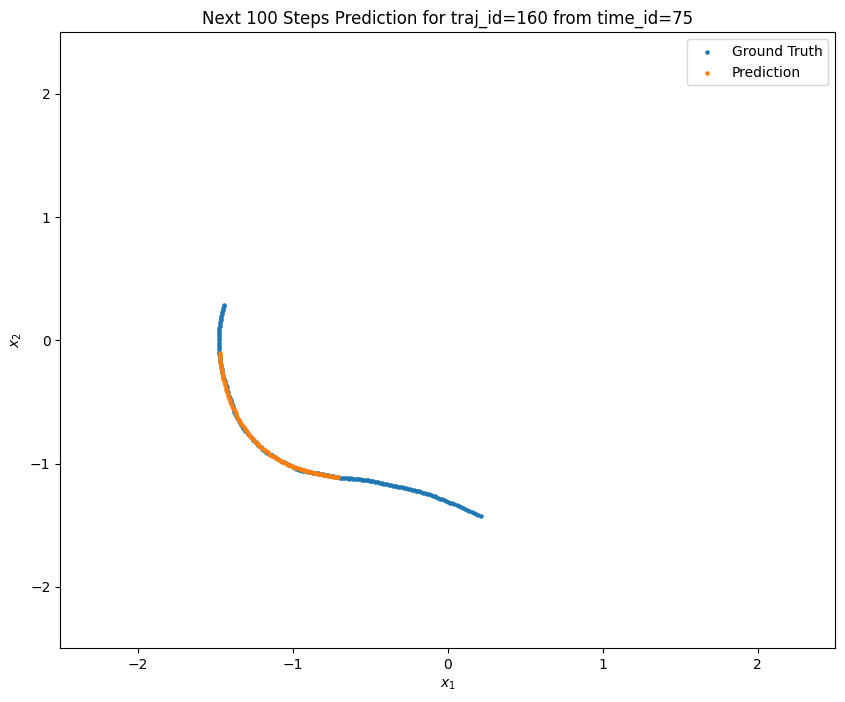

In [60]:
def predict_next_100_steps(X_ode, Xi, traj_id=160, time_id=75,
                            dt_data=0.01, substeps=5):
    """
    Predict the next 100 time steps starting from a data-based initial condition.
    """

    n_steps = 100
    dt_sim = dt_data / substeps
    n = X_ode.shape[2]

    # initial condition from data (must be within first 301 steps)
    x0 = X_ode[traj_id, time_id].copy()

    # storage
    x_pred = np.zeros((n_steps + 1, n))
    x_pred[0] = x0

    # rollout
    for k in range(n_steps):
        x = x_pred[k].copy()
        for _ in range(substeps):
            x = rk4_step(x, dt_sim, f_learned, Xi)
        x_pred[k + 1] = x

    # ground truth for comparison
    x_true = X_ode[traj_id, time_id:time_id + n_steps + 1]
    for x in range (200, 201):
        plt.figure(figsize=(10, 8))
        for traj in X_ode[traj_id:traj_id+1,:,:]:
            plt.scatter(x=traj[:x,0], y=traj[:x,1], s=5, label="Ground Truth")
            plt.xlabel(r"$x_1$")
            plt.ylabel(r"$x_2$")
            
            # plt.xlim(-2.5, 2.5)
            # plt.ylim(-2.5, 2.5)
    # plot prediction vs ground truth
    plt.scatter(x=x_pred[:, 0], y=x_pred[:, 1], s=5, label="Prediction")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.legend()
    plt.title("Next 100 Steps Prediction for traj_id={} from time_id={}".format(traj_id, time_id))
    plt.show()

    return x_pred, x_true


# run prediction
x_pred, x_true = predict_next_100_steps(X_ode, Xi)


/var/folders/xs/gpxs1c4d1gqfh80p76l8mqmr0000gn/T/ipykernel_52891/3864177210.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


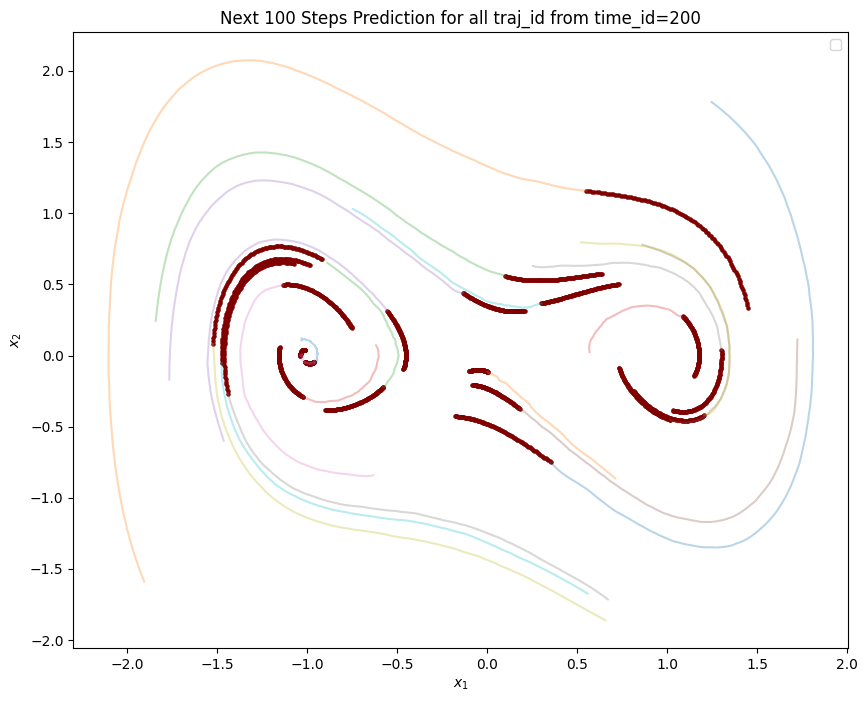

In [61]:
# -------------------------------------------------------
# Predict the next 100 time steps using the learned ODE
# -------------------------------------------------------

def predict_next_100_steps(X_ode, Xi, traj_id=7, time_id=200,
                            dt_data=0.01, substeps=5):
    """
    Predict the next 100 time steps starting from a data-based initial condition.
    """
    plt.figure(figsize=(10, 8))
    for traj_id in range(0,20):
        n_steps = 100
        dt_sim = dt_data / substeps
        n = X_ode.shape[2]

        # initial condition from data (must be within first 301 steps)
        x0 = X_ode[traj_id, time_id].copy()

        # storage
        x_pred = np.zeros((n_steps + 1, n))
        x_pred[0] = x0

        # rollout
        for k in range(n_steps):
            x = x_pred[k].copy()
            for _ in range(substeps):
                x = rk4_step(x, dt_sim, f_learned, Xi)
            x_pred[k + 1] = x

        # ground truth for comparison
        x_true = X_ode[traj_id, time_id:time_id + n_steps + 1]
        

        for traj in X_ode[traj_id:traj_id+1,:,:]:
            plt.plot(traj[:,0], traj[:,1], alpha=0.3)
            
                # plt.xlim(-2.5, 2.5)
                # plt.ylim(-2.5, 2.5)
        # plot prediction vs ground truth
        plt.scatter(x=x_pred[:, 0], y=x_pred[:, 1], s=5,color='#800000' )
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")
        # plt.xlim(-2.5, 2.5)
        # plt.ylim(-2.5, 2.5)
        plt.legend()
    plt.title("Next 100 Steps Prediction for all traj_id from time_id={}".format(time_id))
    plt.show()

    return x_pred, x_true


# run prediction
x_pred, x_true = predict_next_100_steps(X_ode, Xi)


/var/folders/xs/gpxs1c4d1gqfh80p76l8mqmr0000gn/T/ipykernel_52891/20146019.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


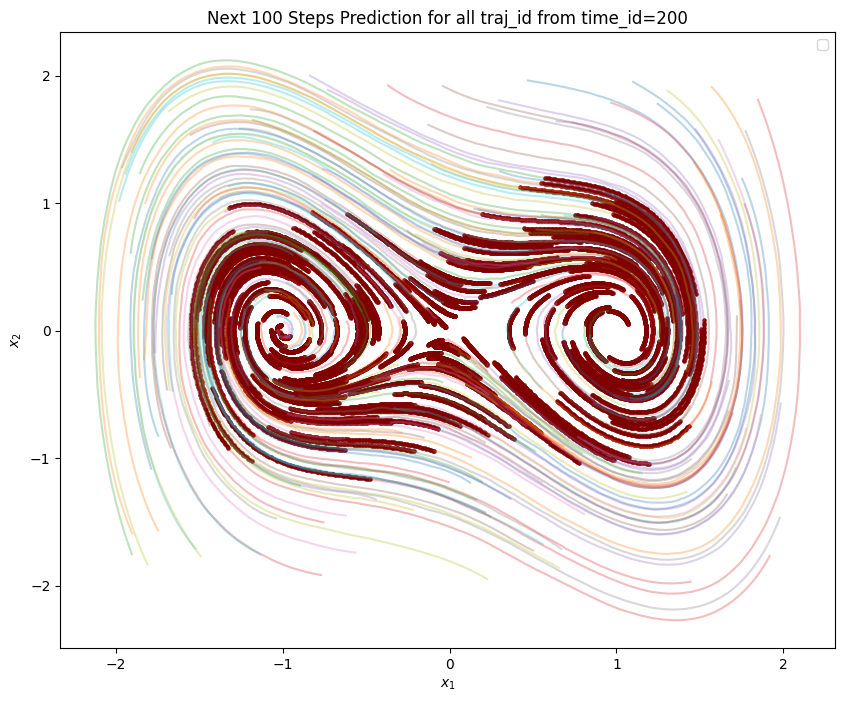

In [ ]:

# Predict the next 100 time steps using the learned ODE


def predict_next_100_steps(X_ode, Xi, traj_id=7, time_id=200,
                            dt_data=0.01, substeps=5):
    """
    Predict the next 100 time steps starting from a data-based initial condition.
    """
    plt.figure(figsize=(10, 8))
    for traj_id in range(0,200):
        n_steps = 100
        dt_sim = dt_data / substeps
        n = X_ode.shape[2]

        # initial condition from data (must be within first 301 steps)
        x0 = X_ode[traj_id, time_id].copy()

        # storage
        x_pred = np.zeros((n_steps + 1, n))
        x_pred[0] = x0

        # rollout
        for k in range(n_steps):
            x = x_pred[k].copy()
            for _ in range(substeps):
                x = rk4_step(x, dt_sim, f_learned, Xi)
            x_pred[k + 1] = x

        # ground truth for comparison
        x_true = X_ode[traj_id, time_id:time_id + n_steps + 1]
        

        for traj in X_ode[traj_id:traj_id+1,:,:]:
            plt.plot(traj[:,0], traj[:,1], alpha=0.3)
            
                # plt.xlim(-2.5, 2.5)
                # plt.ylim(-2.5, 2.5)
        # plot prediction vs ground truth
        plt.scatter(x=x_pred[:, 0], y=x_pred[:, 1], s=5,color='#800000' )
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")
        # plt.xlim(-2.5, 2.5)
        # plt.ylim(-2.5, 2.5)
        plt.legend()
    plt.title("Next 100 Steps Prediction for all traj_id from time_id={}".format(time_id))
    plt.show()

    return x_pred, x_true


# run prediction
x_pred, x_true = predict_next_100_steps(X_ode, Xi)


/var/folders/xs/gpxs1c4d1gqfh80p76l8mqmr0000gn/T/ipykernel_52891/1348315236.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


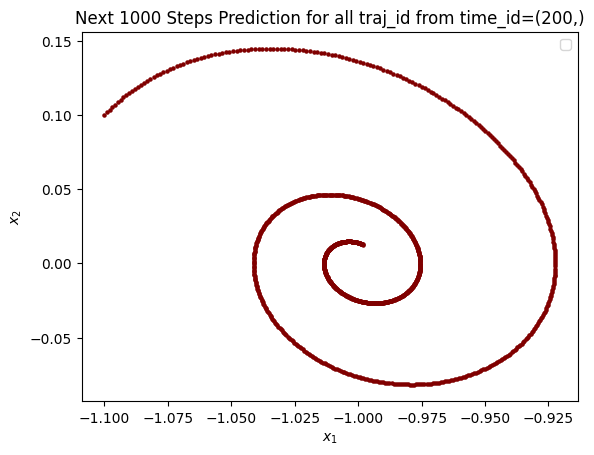

In [63]:
traj_id=7
time_id=200,
dt_data=0.01
substeps=5
n_steps = 1000
dt_sim = dt_data / substeps
n = X_ode.shape[2]

# initial condition from data (must be within first 301 steps)
x0 = [-1.1,0.1]

# storage
x_pred = np.zeros((n_steps + 1, n))
x_pred[0] = x0

# rollout
for k in range(n_steps):
    x = x_pred[k].copy()
    for _ in range(substeps):
        x = rk4_step(x, dt_sim, f_learned, Xi)
    x_pred[k + 1] = x

# ground truth for comparison
# x_true = X_ode[traj_id, time_id:time_id + n_steps + 1]


# for traj in X_ode[traj_id:traj_id+1,:,:]:
#     plt.plot(traj[:,0], traj[:,1], alpha=0.3)
    
        # plt.xlim(-2.5, 2.5)
        # plt.ylim(-2.5, 2.5)
# plot prediction vs ground truth
plt.scatter(x=x_pred[:, 0], y=x_pred[:, 1], s=5,color='#800000' )
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
# plt.xlim(-2.5, 2.5)
# plt.ylim(-2.5, 2.5)
plt.legend()
plt.title("Next {} Steps Prediction for all traj_id from time_id={}".format(n_steps,time_id))
plt.show()

In [ ]:
# Define the vector field function
def vector_field(x):
    """
    Example vector field function.
    x: A 2D point [x1, x2]
    Returns: A vector [dx1/dt, dx2/dt]
    """
    x1, x2 = x
    dx1_dt = -x1 + x2
    dx2_dt = -x2 - x1
    return np.array([dx1_dt, dx2_dt])

# Define the grid for the space [-2, 2]^2
x1 = np.linspace(-2, 2, 100)
x2 = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1, x2)

# Initialize the basin of attraction grid
basin = np.zeros_like(X1)

# Define the equilibrium point (attractor)
x_eq = np.array([0.0, 0.0])

# Tolerance for convergence
tol = 1e-2

# Simulate the system for each initial condition in the grid
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        for _ in range(1000):  # Maximum number of iterations
            x = x + 0.01 * vector_field(x)  # Euler integration
            if np.linalg.norm(x - x_eq) < tol:
                basin[i, j] = 1  # Mark as part of the basin of attraction
                break

# Plot the basin of attraction
plt.figure(figsize=(8, 8))
plt.contourf(X1, X2, basin, levels=1, cmap="coolwarm", alpha=0.8)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Basin of Attraction")
plt.grid()
plt.show()


In [64]:

# ---------- helpers ----------
def simulate_to_asymptotic(
    x0, Xi, dt=0.01, T=30.0,
    tail_steps=400, eq_tol=1e-6, eq_window=80
):
    """
    Integrate forward and return:
      - tail: last tail_steps states (for equilibrium / cycle heuristics)
      - x_rep: representative state (mean of tail)
      - is_eq: whether trajectory looks like equilibrium (low tail variance)
    """
    steps = int(T / dt)
    x = np.array(x0, dtype=float)

    tail = np.zeros((tail_steps, len(x)), dtype=float)
    tcount = 0

    # For early stopping: keep a rolling window of step-to-step changes
    dwin = np.zeros(eq_window, dtype=float)
    dptr = 0
    filled = 0

    for k in range(steps):
        x_new = rk4_step(x, dt, f_learned, Xi)
        dx = np.linalg.norm(x_new - x)
        x = x_new

        # update convergence window
        dwin[dptr] = dx
        dptr = (dptr + 1) % eq_window
        filled = min(filled + 1, eq_window)

        # start filling tail near the end, but also keep updating if we early stop
        if k >= steps - tail_steps:
            tail[tcount] = x
            tcount += 1

        # early stop if changes are tiny for a while (equilibrium-like)
        if filled == eq_window and np.max(dwin) < eq_tol:
            # finish tail by repeating last state (so downstream code is consistent)
            if tcount == 0:
                # we didn't reach the "last tail_steps" region yet; synthesize tail
                tail[:] = x
            else:
                tail[tcount:] = x
            break

    # If we didn’t fill tail because T too short, pad with last state
    if tcount < tail_steps:
        tail[tcount:] = x

    x_rep = tail.mean(axis=0)
    tail_std = tail.std(axis=0)
    is_eq = np.linalg.norm(tail_std) < 1e-3  # heuristic; tune if needed

    return x_rep, tail, is_eq


In [65]:

def cluster_endpoints(endpoints, radius=None):
    """
    Simple greedy clustering (no sklearn): assign a cluster id if endpoint is close
    to an existing cluster center, else create a new cluster.
    """
    endpoints = np.asarray(endpoints)
    if radius is None:
        # auto radius: 1% of diagonal of endpoint cloud
        mins = endpoints.min(axis=0)
        maxs = endpoints.max(axis=0)
        diag = np.linalg.norm(maxs - mins)
        radius = 0.01 * diag + 1e-12

    centers = []
    labels = np.empty(len(endpoints), dtype=int)

    for idx, p in enumerate(endpoints):
        if len(centers) == 0:
            centers.append(p.copy())
            labels[idx] = 0
            continue

        dists = np.linalg.norm(np.vstack(centers) - p[None, :], axis=1)
        j = int(np.argmin(dists))
        if dists[j] <= radius:
            labels[idx] = j
            # update center (online mean)
            centers[j] = 0.9 * centers[j] + 0.1 * p
        else:
            labels[idx] = len(centers)
            centers.append(p.copy())

    return labels, np.vstack(centers), radius


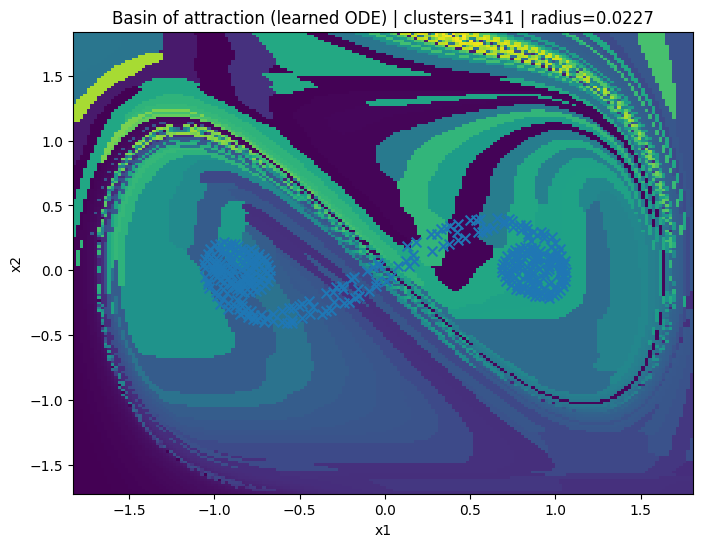

In [66]:
# ---------- grid bounds ----------
x1min, x1max = np.percentile(X_ode[:, :, 0].ravel(), [1, 99])
x2min, x2max = np.percentile(X_ode[:, :, 1].ravel(), [1, 99])

pad1 = 0.2 * (x1max - x1min)
pad2 = 0.2 * (x2max - x2min)
# x1min, x1max = x1min - pad1, x1max + pad1
# x2min, x2max = x2min - pad2, x2max + pad2

nx, ny = 180, 180
x1_grid = np.linspace(x1min, x1max, nx)
x2_grid = np.linspace(x2min, x2max, ny)

# ---------- simulate ----------
dt_sim = 0.1     # MUCH safer than 0.1 for learned ODEs
T_sim  = 10.0     # more time to settle
endpoints = np.zeros((nx * ny, 2), dtype=float)


idx = 0
for j, x2 in enumerate(x2_grid):
    for i, x1 in enumerate(x1_grid):
        x_rep, tail, is_eq = simulate_to_asymptotic([x1, x2], Xi, dt=dt_sim, T=T_sim)
        # For cycles, mean(tail) can collapse different phases to same point;
        # still OK for "basin regions", but if you see artifacts, use tail features instead.
        endpoints[idx] = x_rep
        idx += 1

# ---------- cluster endpoints -> basin labels ----------
labels, centers, rad = cluster_endpoints(endpoints, radius=None)

basin = labels.reshape(ny, nx)  # imshow expects [rows(y), cols(x)]

# ---------- plot ----------
plt.figure(figsize=(8, 6))
plt.imshow(
    basin,
    origin="lower",
    extent=[x1min, x1max, x2min, x2max],
    interpolation="nearest",
    aspect="auto",
)
plt.scatter(centers[:, 0], centers[:, 1], s=50, marker="x")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Basin of attraction (learned ODE) | clusters={len(centers)} | radius={rad:.3g}")
plt.show()

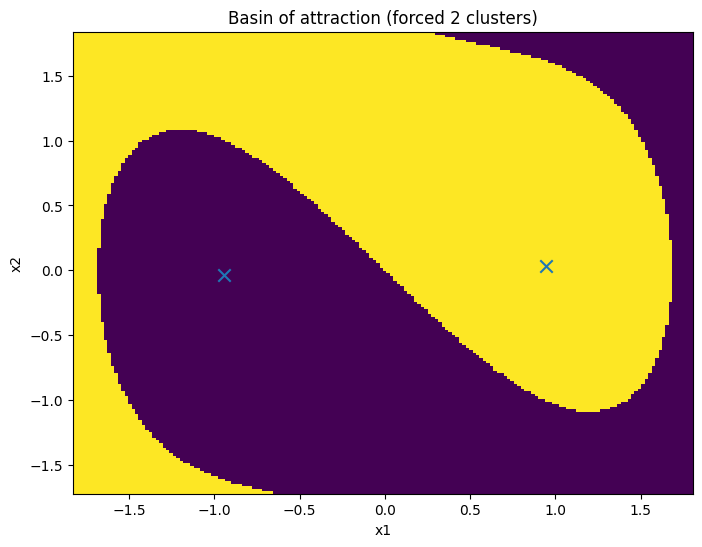

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def kmeans_2(X, iters=50, seed=0):
    """
    K-means with k=2 (pure numpy). Returns labels in {0,1} and the 2 centers.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, float)

    # init: pick 1 random point, 2nd = farthest from it (stable-ish)
    i0 = rng.integers(len(X))
    c0 = X[i0]
    i1 = np.argmax(np.linalg.norm(X - c0, axis=1))
    c1 = X[i1]
    C = np.vstack([c0, c1])

    for _ in range(iters):
        # assign
        d0 = np.linalg.norm(X - C[0], axis=1)
        d1 = np.linalg.norm(X - C[1], axis=1)
        labels = (d1 < d0).astype(int)

        # update
        newC = C.copy()
        for k in (0, 1):
            mask = labels == k
            if np.any(mask):
                newC[k] = X[mask].mean(axis=0)

        if np.allclose(newC, C):
            break
        C = newC

    return labels, C


# --- after you've computed `endpoints` (shape: (nx*ny, 2)) ---
labels2, centers2 = kmeans_2(endpoints, iters=800, seed=1)
basin = labels2.reshape(ny, nx)

plt.figure(figsize=(8, 6))
plt.imshow(
    basin,
    origin="lower",
    extent=[x1min, x1max, x2min, x2max],
    interpolation="nearest",
    aspect="auto"
)
plt.scatter(centers2[:, 0], centers2[:, 1], marker="x", s=80)
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Basin of attraction (forced 2 clusters)")
plt.show()
